In [1]:
#Note : this code can sweep multiple gap and run, simple circular ring, collecting full Tx spectrum at different gaps

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import time
from tqdm import tqdm

total_start = time.time()
# Directory = r'D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing'
# os.chdir(Directory)
pwd = os.getcwd()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

REPO_ROOT = Path(pwd).resolve().parents[1]
WORKDIR = REPO_ROOT / "scripts" / "RingMod_Squeezing"
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_RingMod_Squeezing"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing
Data will be saved to: D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing


In [3]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'Ring60um_check.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


In [4]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1540E-9
LambdaStop     = 1570E-9

Width          = 1500E-9
Height         = 200E-9
Radius         = 60E-6
Gap            = 600E-9
Length         = 4 * Radius
YLength        = Radius
Material       = "Si3N4 (Silicon Nitride) - Luke"
CouplingLength = 0.0E-6
Index          = 2; #optional
decay_time     = 1E-5

BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 1200E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(2000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 60000


Mode numbers: [371]
Relative μ: [0]
Amplitudes (nm): [0.]
Minimum radius: 1.50 µm
Maximum radius: 1.50 µm
Ring Area: 565.49 µm²
Modulated Ring Area: 565.49 µm²
Area Difference due to modulation: 0.00 µm²


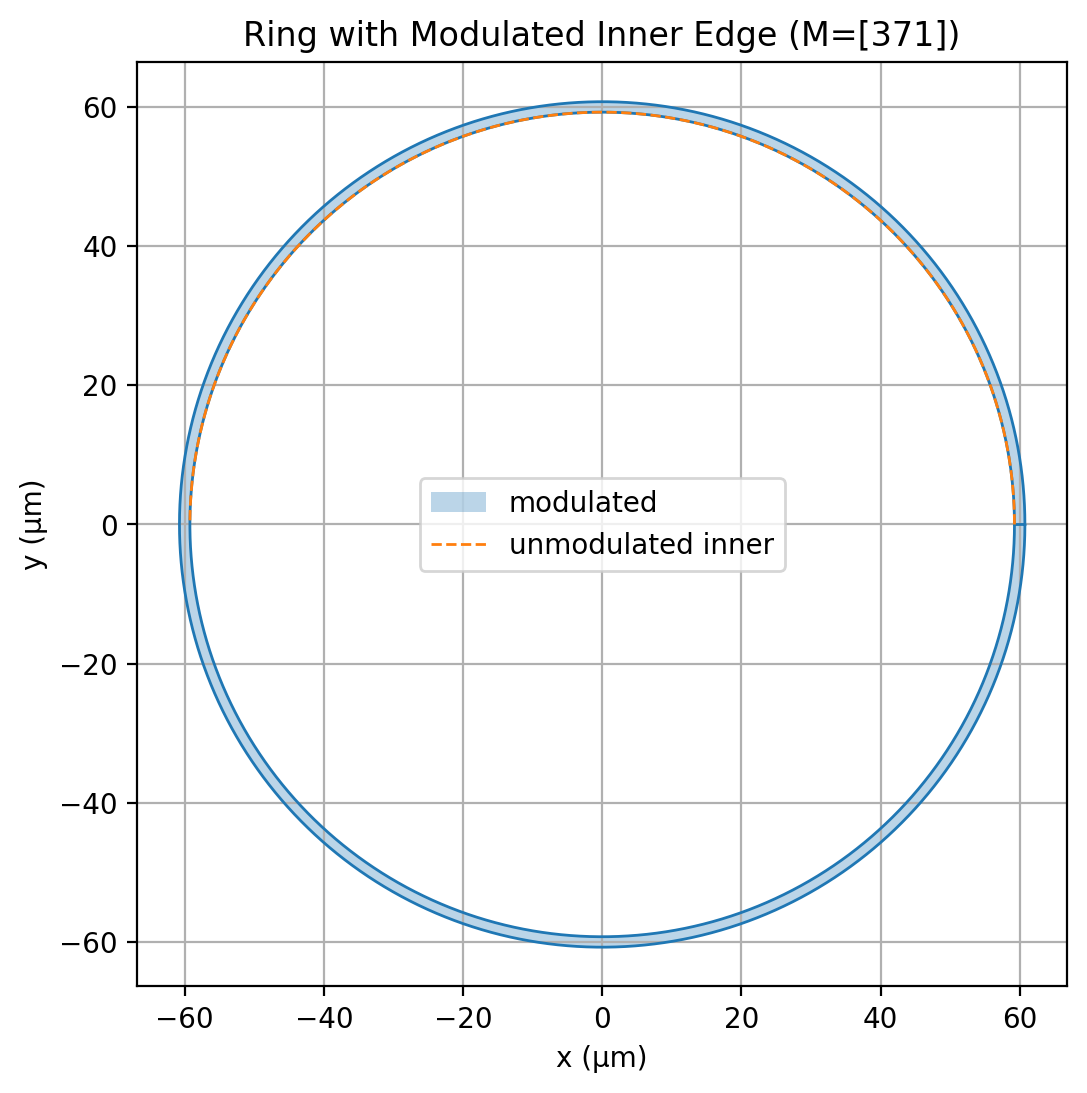

Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.


In [5]:
# --- Mode number tracking ---------------

M_ref = 371 # Mode numbers (using 300 as reference μ=0)
# M     = np.array(np.linspace(370,373,2))
M = [371]  # Mode numbers to be modulated
mu    = np.array(M) - M_ref  # Relative mode numbers: [1, 2, 5, 10, 20]
print(f"Mode numbers: {M}")
print(f"Relative μ: {mu}")

# --- Amplitude of modulation ---------------

A_max = 0E-9
# A = A_max*(abs(mu)/np.max(mu))**2  # Amplitude of modulation
A = A_max*np.ones_like(mu)     # Amplitude of modulation
print(f"Amplitudes (nm): {A*1e9}")
Npoints = max(5000, 300*M_ref)  # Number of points for smoothness

#--- Modulated Ring Generation --------------

def generate_full_ring(Radius=4e-6,
                                    width=700e-9,
                                    A=300e-9,
                                    M=50,
                                    Npoints=1000):
    theta         = np.linspace(0, 2*np.pi, Npoints)
    R_inner_base  = Radius - width/2
    R_outer_base  = Radius + width/2

    # ensure A_list, M_list
    A_list = np.atleast_1d(A)
    M_list = np.atleast_1d(M)

    # sum of cosines
    modulation = np.zeros_like(theta)
    for i, (Ai, Mi) in enumerate(zip(A_list, M_list)):
        
        if Mi == 0:
            # No modulation for M=0
            modulation += Ai
        else:
            # Normalized modulation
            # modulation += Ai * (np.cos(2*Mi * theta + (2*np.pi/ (i+1))))
            modulation += Ai * np.cos(2*Mi * theta + (2*np.pi/len(M_list))*i)

    R_inner       = R_inner_base - modulation
    R_outer_const = R_outer_base
    
    min_radius = np.min(R_outer_const-R_inner)
    print(f"Minimum radius: {min_radius*1e6:.2f} µm")
    
    max_radius = np.max(R_outer_const-R_inner)
    print(f"Maximum radius: {max_radius*1e6:.2f} µm")

    RingArea = np.pi * (R_outer_const**2 - R_inner_base**2)
    print(f"Ring Area: {RingArea*1e12:.2f} µm²")
    
    ModRingArea = np.pi * (R_outer_const**2 - np.mean(R_inner**2))
    print(f"Modulated Ring Area: {ModRingArea*1e12:.2f} µm²")
    
    AreaDiff = ModRingArea - RingArea
    print(f"Area Difference due to modulation: {AreaDiff*1e12:.2f} µm²")

    # Outer arc θ=0→π (not reversed)
    x_outer = R_outer_base * np.cos(theta)
    y_outer = R_outer_base * np.sin(theta)

    # Inner arc θ=π→0 (reversed)
    x_inner = R_inner * np.cos(theta[::-1])  
    y_inner = R_inner * np.sin(theta[::-1])

    x_poly = np.concatenate([x_outer, x_inner])
    y_poly = np.concatenate([y_outer, y_inner])

    return x_poly, y_poly

x_poly, y_poly = generate_full_ring(Radius=Radius ,
                                            width=Width, A = A, M=M, Npoints=Npoints)
# compute unmodulated inner ring
theta_base   = np.linspace(0, np.pi, Npoints)
R_inner_base = Radius - Width/2
x_base       = R_inner_base * np.cos(theta_base)
y_base       = R_inner_base * np.sin(theta_base)

# visualize
plt.figure(figsize=(6,6))
plt.fill(x_poly*1e6, y_poly*1e6, alpha=0.3, label='modulated')
plt.plot(x_poly*1e6, y_poly*1e6, '-', linewidth=1)
plt.plot(x_base*1e6, y_base*1e6, '--', linewidth=1, label='unmodulated inner')
plt.axis('equal')
plt.gcf().set_dpi(200)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Ring with Modulated Inner Edge (M={M})')
plt.legend()
plt.grid()

# Save figure as high-res PNG for zooming in
plt.savefig("modulated_ring_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.")

In [6]:
def start_section(name):
    print(f"🏃 {name}...", end=" ", flush=True)
    return time.time()

def end_section(start):
    print(f"✅ {time.time() - start:.1f}s")


🚀 Starting Gap Sweep | 1 points



Gap Sweep:   0%|                                          | 0/1 [00:00<?, ?it/s]


--- Gap 1/1: 600 nm ---
🏃 Geometry setup... 🏃 Geometry Setup... ✅ 147.0s
🏃 varFDTD + Source + Monitos setup... Center of modulated ring: xc=0.00 µm, yc=-60.00 µm
Dimension summary (µm):
x0: -60.00, y0: 0.00
Test point (µm): [[-60.   60.   60.  -60. ]
 [  0.    0.    0.1   0.1]]
✅ 1.0s
🏃 Running simulation... ✅ 2219.9s


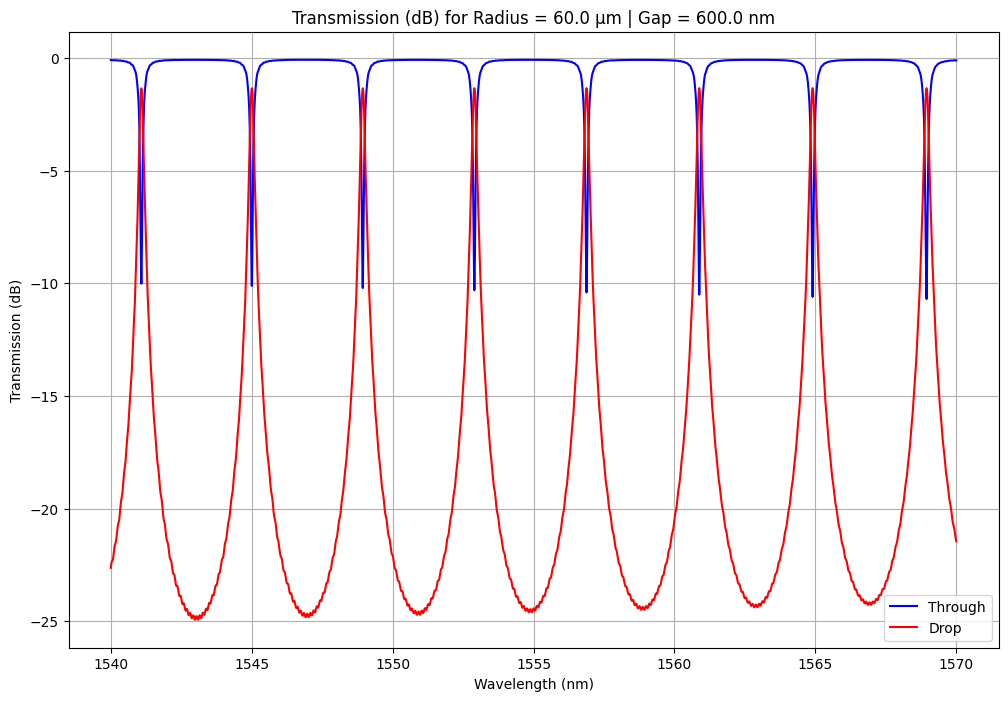

Gap Sweep: 100%|████████████████████████████████| 1/1 [39:28<00:00, 2368.28s/it]

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_Ring60um_check_gap600.00nm_Tx.txt
🎉 Gap 600.0 nm complete!

⏱️ Total time: 39.6 min

🏆 All 1 sweeps complete!
Empty DataFrame
Columns: []
Index: []


In [7]:
gaps = [600e-9]  # start below current
# coupling_lengths = [10e-6]
gap_sweep_results = []

print(f"\n{'='*50}")
print(f"🚀 Starting Gap Sweep | {len(gaps)} points")
print(f"{'='*50}\n")

for i, g in enumerate(tqdm(gaps, desc="Gap Sweep", ncols=80)):
    Gap = g
    print(f"\n--- Gap {i+1}/{len(gaps)}: {Gap*1e9:.0f} nm ---")

    t = start_section("Geometry setup")
    f.switchtolayout()
    f.selectall()
    f.delete()
    t = start_section("Geometry Setup")
    #------------------------------------------------------------
    # STRUCTURE GROUP : Ring 
    #------------------------------------------------------------

    group_name = "Ring Resonator Group"
    f.addstructuregroup()
    f.set("name", group_name)
    f.set("construction group", 1)
    f.set("x",0)
    f.set("y",0)
    f.set("z",0)

    # ADD USER PROPERTIES (keep original ones only)
    f.adduserprop("Width",          2, Width)
    f.adduserprop("Height",         2, Height)
    f.adduserprop("Radius",         2, Radius)
    f.adduserprop("Gap",            2, Gap)
    f.adduserprop("Length",         2, Length)
    f.adduserprop("Material",       5, Material)
    f.adduserprop("Index",          0, Index)
    f.adduserprop("CouplingLength", 2, CouplingLength)

    # Convert vertices to Lumerical matrix format
    vertices_str = "["
    for i in range(len(x_poly)):
        vertices_str += f"{x_poly[i]}, {y_poly[i]};"
    vertices_str = vertices_str.rstrip(';') + "]"

    #------------------------------------------------------------
    # GEOMETRY SETUP SCRIPT
    #------------------------------------------------------------

    setup_script = f"""
    # Base waveguides
    addrect;
    set('name','WG1');
    set('x', 0);
    set('x span', Length);
    set('y span', Width);
    set('y', Radius + Gap + Width);
    copy(0, -2 * (Radius + Gap + Width), 0);

    # Modulated Ring using polygon vertices
    addpoly;
    set('name', 'modulated_ring');
    set('vertices', {vertices_str});

    # Assign materials & finalize structure
    selectall;
    set('material', Material);
    if (Material == '<Object defined dielectric>') {{
        set('index', Index);
    }}
    set('z min', 0);
    set('z max', Height);
    """

    f.set("script", setup_script)

    end_section(t)

    t = start_section("varFDTD + Source + Monitos setup")
    xc = 0.5 * (np.max(x_poly) + np.min(x_poly)) 
    yc = 0.5 * (np.max(y_poly) + np.min(y_poly))-YLength
    print(f"Center of modulated ring: xc={xc*1e6:.2f} µm, yc={yc*1e6:.2f} µm")

    # varFDTS bounds
    x0 = -Radius-CouplingLength/2
    y0 = 0

    margin = 2 * LambdaStop

    x_fdtd_span = 2.5 * Radius + CouplingLength/2
    y_fdtd_span = 2.5 * (Radius + Gap + Width)

    print(f"Dimension summary (µm):")
    print(f"x0: {x0*1e6:.2f}, y0: {y0*1e6:.2f}")

    test_points = np.zeros((2, 4))

    test_points[0,0] = x0
    test_points[1,0] = y0

    test_points[0,1] = -x0
    test_points[1,1] = y0

    test_points[0,2] = -x0
    test_points[1,2] = y0+0.1E-6

    test_points[0,3] = x0
    test_points[1,3] = y0+0.1E-6

    print("Test point (µm):", test_points*1e6)

    ## Monitor Positions (relative to FDTD origin) ##

    xpos_through = -x0
    ypos_through = Radius + Gap + Width

    xpos_reflect1 = x0
    ypos_reflect1 = ypos_through

    #------------------------------------------------------------
    # VarFDTD  (RING CENTERED AT x=0, y=0 — CORRECT SETUP)
    #------------------------------------------------------------

    f.addvarfdtd()
    f.set("simulation time", SimulationTime) 
    f.set("x0", x0)              # mode position (that green arrow)
    f.set("y0",y0)
    # f.set("y0", Radius + Gap + Width)
    f.set("x", 0)                    # Centered in X
    f.set("x span", x_fdtd_span)    # Cover full structure
    f.set("y", 0)                    # Centered in Y
    f.set("y span", y_fdtd_span)  # Cover full waveguide & ring
    f.set("z", Height / 2)           # Centered in Z
    f.set("z span", 8*Height)        # Cover height of the structure
    f.set("background material",BackgroundMaterial)
    f.set("set simulation bandwidth",1)
    f.set("bandwidth",'broadband')
    f.set("simulation wavelength min", LambdaStart)
    f.set("simulation wavelength max", LambdaStop)
    f.set("auto shutoff min",decay_time)

    # Boundary Conditions
    f.set("x min bc", "PML")
    f.set("x max bc", "PML")
    f.set("y min bc", "PML")
    f.set("y max bc", "PML")
    f.set("z min bc", "PML")
    f.set("z max bc", "PML")

    # TEST POINT POSITIONS (Blue Arrows) - On the Arc
    theta = [45, 135, 225, 315]   # Angles for test points (degrees)
    test_points = np.zeros((2, 4))  # Creates a 2-row, 4-column matrix for (x, y) coordinates

    for i in range(4):
        angle_rad = theta[i] * np.pi / 180  # Convert degrees to radians
        test_points[0, i] = Radius * np.cos(angle_rad)  # x-coordinate
        test_points[1, i] = Radius * np.sin(angle_rad)  # y-coordinate

    f.set("test points", test_points)

    #------------------------------------------------------------
    # Source
    #------------------------------------------------------------

    f.addmodesource()
    f.set("name", "ModeSource")
    f.set("x", xpos_reflect1 + 1.25*LambdaStop)
    f.set("y", ypos_reflect1)
    f.set("y span", 2 * Width)
    f.set("use relative coordinates", 1)
    f.set("injection axis", "x-axis")
    f.set("direction", "Forward")
    f.set("amplitude", 1.0)
    f.set("phase", 0)
    f.set("mode selection", "fundamental mode")
    f.set("set wavelength", 1)
    f.set("wavelength start", LambdaStart)
    f.set("wavelength stop", LambdaStop)

    #------------------------------------------------------------
    # Monitors 
    #------------------------------------------------------------

    # THROUGH PORT (3)
    f.adddftmonitor()
    f.set("name", "Through")
    f.set("monitor type", "Linear Y")
    f.set("x", xpos_through)
    f.set("y", ypos_through)
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # DROP PORT 
    f.adddftmonitor()
    f.set("name", "Drop")
    f.set("monitor type", "Linear Y")
    f.set("x", xpos_reflect1)
    f.set("y", -ypos_reflect1)
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)
    end_section(t)
    #------------------------------------------------------------
    # Run
    #------------------------------------------------------------
    t = start_section("Running simulation")
    f.run()
    end_section(t)
    #------------------------------------------------------------
    # Save Data
    #------------------------------------------------------------

    T_port2 = f.getresult("Drop", "T")
    T_port3 = f.getresult("Through", "T")

    Tx_Drop = -T_port2["T"].flatten()
    Tx_Through = T_port3["T"].flatten()
    Wavelenghth = T_port2["lambda"].flatten()

    # -----------------------
    plt.figure(figsize=(12,8))
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through)),'b', label='Through')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Drop)),'r', label='Drop')
    plt.title(f'Transmission (dB) for Radius = {Radius*1E6} µm | Gap = {Gap*1E9} nm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission (dB)')
    plt.legend()
    plt.grid()
    plt.show()

    header = f"""Gap={Gap*1e9:.2f}nm Width={Width*1e9:.2f}nm Height={Height*1e9:.2f}nm
    CouplingLength={CouplingLength*1e6:.2f}um Radius={Radius*1e6:.2f}um
    Material={Material} SimTime={SimulationTime*1e12:.2f}ps
    Wavelength(um) Transmission_Through Transmission_Drop"""

    filename = data_save_dir/f"Data_{LumFileName.removesuffix('.lms')}_gap{Gap*1E9:.2f}nm_Tx.txt"
    data = np.column_stack([Wavelenghth*1E6, Tx_Through, Tx_Drop])
    np.savetxt(filename, data, header=header)

    print(f"Data saved to {filename}")
    print(f"🎉 Gap {Gap*1e9:.1f} nm complete!")

print(f"\n⏱️ Total time: {(time.time() - total_start)/60:.1f} min")
print(f"\n{'='*50}")
print(f"🏆 All {len(gaps)} sweeps complete!")
print(f"{'='*50}")

df = pd.DataFrame(gap_sweep_results)
print(df)

